# 02 — H2a: Absolute Growth of Evidence-Based Treatment Searches

**Hypothesis H2a:** Search activity for evidence-based treatments shows a significant positive trend over time across studied countries.

**Method:** OLS linear trend analysis (primary). If assumptions violated → Mann-Kendall trend test (fallback).

**OSF pre-registration:** https://osf.io/7986u

---

**Outcome variable:** Mean search interest across all EBT keywords and languages per country per month.

**Model:** Y(t) = β0 + β1·time + ε
- H2a confirmed if β1 > 0 and p < 0.017 (Bonferroni-corrected α for 3 categories)

## 0. Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates   # tick formatting for time axes
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan  # homoscedasticity test
from scipy import stats
import pymannkendall as mk          # non-parametric trend test (fallback)
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('../data')
OUTPUT_DIR  = Path('../results/H2a')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # create if not exists

# ── Parameters ─────────────────────────────────────────────────────────────────
CATEGORY        = 'evidence_based_treatments'   # ← change for H2b
ALPHA           = 0.05
ALPHA_BONF      = ALPHA / 3    # Bonferroni correction: 3 categories (H2a, H2b, H3)
RANDOM_SEED     = 42

np.random.seed(RANDOM_SEED)

print(f'Category:          {CATEGORY}')
print(f'Alpha (corrected): {ALPHA_BONF:.3f}')


Category:          evidence_based_treatments
Alpha (corrected): 0.017


## 1. Load data

For each country: load all CSV files matching the category, average across keywords and languages → one RSV value per country per month.

In [2]:
def load_country_category(country_dir: Path, category: str) -> pd.DataFrame | None:
    """
    Load all CSV files for a given country and category.
    Returns a DataFrame with date index and one column per keyword (all languages merged).
    Returns None if no valid data found.
    """
    # Glob pattern: category__language__chunkN.csv
    csv_files = sorted(country_dir.glob(f'{category}__*__chunk*.csv'))

    if not csv_files:
        return None

    frames = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, parse_dates=['date'], index_col='date')

            # isPartial=True marks incomplete months at collection boundary — exclude them
            if 'isPartial' in df.columns:
                df = df[df['isPartial'] == False].drop(columns=['isPartial'])

            # Google Trends returns 0 for queries below detection threshold.
            # Treating 0 as NaN avoids biasing the mean downward for low-volume searches.
            df = df.replace(0, np.nan)

            # Drop columns that are entirely NaN (keyword had no data in this country)
            all_zero_cols = df.columns[df.isna().all()]
            if len(all_zero_cols) > 0:
                df = df.drop(columns=all_zero_cols)

            if df.empty or df.shape[1] == 0:
                continue
            frames.append(df)
        except Exception as e:
            print(f'  Warning: could not read {f.name}: {e}')

    if not frames:
        return None

    # Concatenate all language chunks side by side (same date index, different keyword columns)
    combined = pd.concat(frames, axis=1)
    return combined


def aggregate_to_monthly_mean(df: pd.DataFrame) -> pd.Series:
    """
    Per OSF protocol (Indices section):
    mean(search_interest[country, category, all languages, all keywords]) per month.
    axis=1 averages across keyword columns, preserving the date index.
    """
    return df.mean(axis=1)


# ── Find latest data folder ─────────────────────────────────────────────────────
raw_folders = sorted(DATA_DIR.glob('raw_*'))
if not raw_folders:
    raise FileNotFoundError(f'No raw_* folders found in {DATA_DIR}')
LATEST = raw_folders[-1]
print(f'Data folder: {LATEST.name}')

# ── Load all countries ──────────────────────────────────────────────────────────
country_series = {}   # country_code → pd.Series (monthly mean RSV)
missing_report = {}   # country_code → reason for exclusion

country_dirs = sorted([d for d in LATEST.iterdir() if d.is_dir()])

for country_dir in country_dirs:
    code = country_dir.name
    df = load_country_category(country_dir, CATEGORY)

    if df is None:
        missing_report[code] = 'No CSV files found for category'
        continue

    series = aggregate_to_monthly_mean(df)

    # Quality filter: exclude country if > 20% of months are missing
    pct_missing = series.isna().mean()
    if pct_missing > 0.20:
        missing_report[code] = f'Missing data > 20% ({pct_missing:.1%})'
        continue

    country_series[code] = series

print(f'\nCountries loaded: {len(country_series)}')
print(f'Countries excluded: {len(missing_report)}')
if missing_report:
    for code, reason in missing_report.items():
        print(f'  {code}: {reason}')


Data folder: raw_20260417_211800

Countries loaded: 21
Countries excluded: 0


## 2. Build panel: mean across all countries per month

Per OSF protocol H2a: Y(t) = mean search interest **across countries** per month.

In [3]:
# Build DataFrame: rows = months, columns = countries
panel = pd.DataFrame(country_series)
panel.index = pd.to_datetime(panel.index)
panel = panel.sort_index()

# Global mean across all countries per month — outcome variable for H2a OLS
y_global = panel.mean(axis=1)

# Time variable: integer 0, 1, 2, ... (Jan 2018 = 0).
# Using integers rather than raw dates makes β1 interpretable:
# β1 = change in mean RSV per month.
t = np.arange(len(y_global))

print(f'Time range: {y_global.index[0].date()} → {y_global.index[-1].date()}')
print(f'N months: {len(y_global)}')
print(f'N countries: {panel.shape[1]}')
print(f'\nGlobal mean RSV: {y_global.mean():.2f} (SD={y_global.std():.2f})')
print(f'Missing values: {y_global.isna().sum()}')


Time range: 2018-01-01 → 2025-12-01
N months: 96
N countries: 21

Global mean RSV: 28.06 (SD=5.12)
Missing values: 0


## 3. OLS linear trend model

**Model:** Y(t) = β0 + β1·time + ε

**H2a confirmed if:** β1 > 0 AND p < 0.017

In [4]:
# Drop NaN rows — OLS requires complete cases
mask = ~y_global.isna()
y_ols = y_global[mask].values
t_ols = t[mask]

# sm.add_constant prepends a column of 1s → allows estimating the intercept β0
X = sm.add_constant(t_ols)
model = sm.OLS(y_ols, X).fit()

beta0 = model.params[0]   # intercept: estimated RSV at t=0 (Jan 2018)
beta1 = model.params[1]   # trend: monthly change in mean RSV
p_val = model.pvalues[1]  # p-value for the trend coefficient
r2    = model.rsquared    # variance explained by the linear trend
ci    = model.conf_int()  # 95% confidence intervals for all params

print('═' * 50)
print('OLS Linear Trend Results')
print('═' * 50)
print(f'β0 (intercept):  {beta0:.3f}')
print(f'β1 (trend):      {beta1:.4f}  [95% CI: {ci[1][0]:.4f}, {ci[1][1]:.4f}]')
print(f'p-value:         {p_val:.4f}')
print(f'R²:              {r2:.4f}')
print(f'N:               {len(y_ols)}')
print()
print(f'Bonferroni α:    {ALPHA_BONF:.3f}')
sig = '✓ SIGNIFICANT' if (p_val < ALPHA_BONF and beta1 > 0) else '✗ NOT significant'
print(f'H2a result:      {sig}')


══════════════════════════════════════════════════
OLS Linear Trend Results
══════════════════════════════════════════════════
β0 (intercept):  21.577
β1 (trend):      0.1364  [95% CI: 0.1112, 0.1616]
p-value:         0.0000
R²:              0.5515
N:               96

Bonferroni α:    0.017
H2a result:      ✓ SIGNIFICANT


## 4. Assumption checks

Per OSF protocol:
1. **Normality of residuals** — Shapiro-Wilk test
2. **Homoscedasticity** — Breusch-Pagan test

If either violated → use Mann-Kendall as fallback.

In [5]:
residuals = model.resid

# 1. Shapiro-Wilk — tests if residuals are normally distributed.
#    H0: residuals are normal. p < α → violated.
sw_stat, sw_p = stats.shapiro(residuals)
normality_ok = sw_p >= ALPHA

# 2. Breusch-Pagan — tests if residual variance is constant (homoscedasticity).
#    H0: variance is homoscedastic. p < α → violated (heteroscedasticity).
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)
homoscedasticity_ok = bp_p >= ALPHA

print('Assumption Checks')
print('-' * 40)
print(f'Shapiro-Wilk (normality):')
print(f'  W={sw_stat:.4f}, p={sw_p:.4f}  → {"OK" if normality_ok else "VIOLATED"}')
print()
print(f'Breusch-Pagan (homoscedasticity):')
print(f'  stat={bp_stat:.4f}, p={bp_p:.4f}  → {"OK" if homoscedasticity_ok else "VIOLATED"}')

assumptions_ok = normality_ok and homoscedasticity_ok
print()
if assumptions_ok:
    print('✓ Both assumptions met — OLS results are valid.')
else:
    print('⚠ One or more assumptions violated — Mann-Kendall fallback will be used.')


Assumption Checks
----------------------------------------
Shapiro-Wilk (normality):
  W=0.8582, p=0.0000  → VIOLATED

Breusch-Pagan (homoscedasticity):
  stat=3.0106, p=0.0827  → OK

⚠ One or more assumptions violated — Mann-Kendall fallback will be used.


## 5. Mann-Kendall fallback

Non-parametric trend test. Applied if OLS assumptions are violated.

In [6]:
# Mann-Kendall is a non-parametric rank-based test for monotonic trend.
# It makes no assumptions about the distribution of residuals,
# making it robust when OLS normality/homoscedasticity assumptions are violated.
# We run it regardless and report as supplementary even if OLS is primary.
mk_result = mk.original_test(y_ols)

print('Mann-Kendall Trend Test')
print('-' * 40)
print(f'Trend:       {mk_result.trend}')
print(f'Tau (τ):     {mk_result.Tau:.4f}')  # Kendall's τ: effect size, range [-1, 1]
print(f'p-value:     {mk_result.p:.4f}')
print(f's:           {mk_result.s}')         # Mann-Kendall S statistic
print(f'z:           {mk_result.z:.4f}')
print()
mk_sig = '✓ SIGNIFICANT' if (mk_result.p < ALPHA_BONF and mk_result.trend == 'increasing') else '✗ NOT significant'
print(f'H2a result (MK): {mk_sig}')

# Decide which method is primary based on assumption checks
print()
print('─' * 40)
if assumptions_ok:
    print('PRIMARY METHOD: OLS')
    print('Mann-Kendall: reported as supplementary')
else:
    print('PRIMARY METHOD: Mann-Kendall (OLS assumptions violated)')
    print('OLS: reported as supplementary')


Mann-Kendall Trend Test
----------------------------------------
Trend:       increasing
Tau (τ):     0.5996
p-value:     0.0000
s:           2734.0
z:           8.6506

H2a result (MK): ✓ SIGNIFICANT

────────────────────────────────────────
PRIMARY METHOD: Mann-Kendall (OLS assumptions violated)
OLS: reported as supplementary


## 5b. Sensitivity — Google Trends 2022 artifact check

Per Myburgh (2022, IJERPH 19(22):15396), Google Trends updated its data collection
methodology effective **1 January 2022**, producing systematically higher RSV values
from that date. This could artificially inflate the estimated trend slope β₁.

**Sensitivity:** re-run OLS and Mann-Kendall on **2018–2021 data only**.
If β₁ > 0 and significant in pre-2022 data → finding is robust.


In [7]:
# ── Google Trends 2022 artifact — sensitivity analysis ────────────────────────
# Google Trends updated its sampling methodology effective 1 January 2022,
# resulting in systematically higher RSV values from that date (Myburgh, 2022).
# This could artificially inflate β1 (trend) in the full-period OLS.
#
# Sensitivity: re-run OLS and Mann-Kendall using ONLY pre-2022 data (2018–2021).
# If trend is significant in pre-2022 data → result is robust to the GT artifact.

PRE_2022_END = pd.Timestamp('2021-12-31')

y_pre  = y_global[y_global.index <= PRE_2022_END]
t_pre  = np.arange(len(y_pre))

mask_pre  = ~y_pre.isna()
y_ols_pre = y_pre[mask_pre].values
t_ols_pre = t_pre[mask_pre]

# OLS — pre-2022
X_pre        = sm.add_constant(t_ols_pre)
model_pre    = sm.OLS(y_ols_pre, X_pre).fit()
beta1_pre    = model_pre.params[1]
p_val_pre    = model_pre.pvalues[1]
r2_pre       = model_pre.rsquared

# Mann-Kendall — pre-2022
mk_pre = mk.original_test(y_ols_pre)

print('Google Trends 2022 Artifact — Sensitivity Analysis')
print('Period: 2018–2021 only (pre-GT-methodology-change)')
print('=' * 55)
print(f'N months (pre-2022): {len(y_ols_pre)}')
print()
print('OLS:')
print(f'  β1 (trend):  {beta1_pre:.4f}  p={p_val_pre:.4f}  R²={r2_pre:.4f}')
sig_pre = p_val_pre < ALPHA_BONF and beta1_pre > 0
print(f'  H2a (pre-2022): {"SUPPORTED" if sig_pre else "NOT SUPPORTED"}')
print()
print('Mann-Kendall:')
print(f'  trend={mk_pre.trend}  τ={mk_pre.Tau:.4f}  p={mk_pre.p:.4f}')
print()

# Consistency check
full_sig  = (p_val < ALPHA_BONF and beta1 > 0)
pre_sig   = sig_pre
direction_ok = (beta1 > 0) == (beta1_pre > 0)

print('Consistency with full-period results:')
print(f'  Direction consistent: {"✓" if direction_ok else "✗  DIFFERS"}')
print(f'  Full period significant: {full_sig}')
print(f'  Pre-2022 significant:    {pre_sig}')
if full_sig and pre_sig:
    print('  → ✓ Robust: trend significant in both periods')
elif full_sig and not pre_sig:
    print('  → ⚠ Caution: trend significant only in full period')
    print('    (post-2022 GT artifact may contribute to significance)')
else:
    print('  → Neither period shows significant trend')


Google Trends 2022 Artifact — Sensitivity Analysis
Period: 2018–2021 only (pre-GT-methodology-change)
N months (pre-2022): 48

OLS:
  β1 (trend):  -0.0078  p=0.7503  R²=0.0022
  H2a (pre-2022): NOT SUPPORTED

Mann-Kendall:
  trend=no trend  τ=0.0071  p=0.9504

Consistency with full-period results:
  Direction consistent: ✗  DIFFERS
  Full period significant: True
  Pre-2022 significant:    False
  → ⚠ Caution: trend significant only in full period
    (post-2022 GT artifact may contribute to significance)


## 6. Visualization

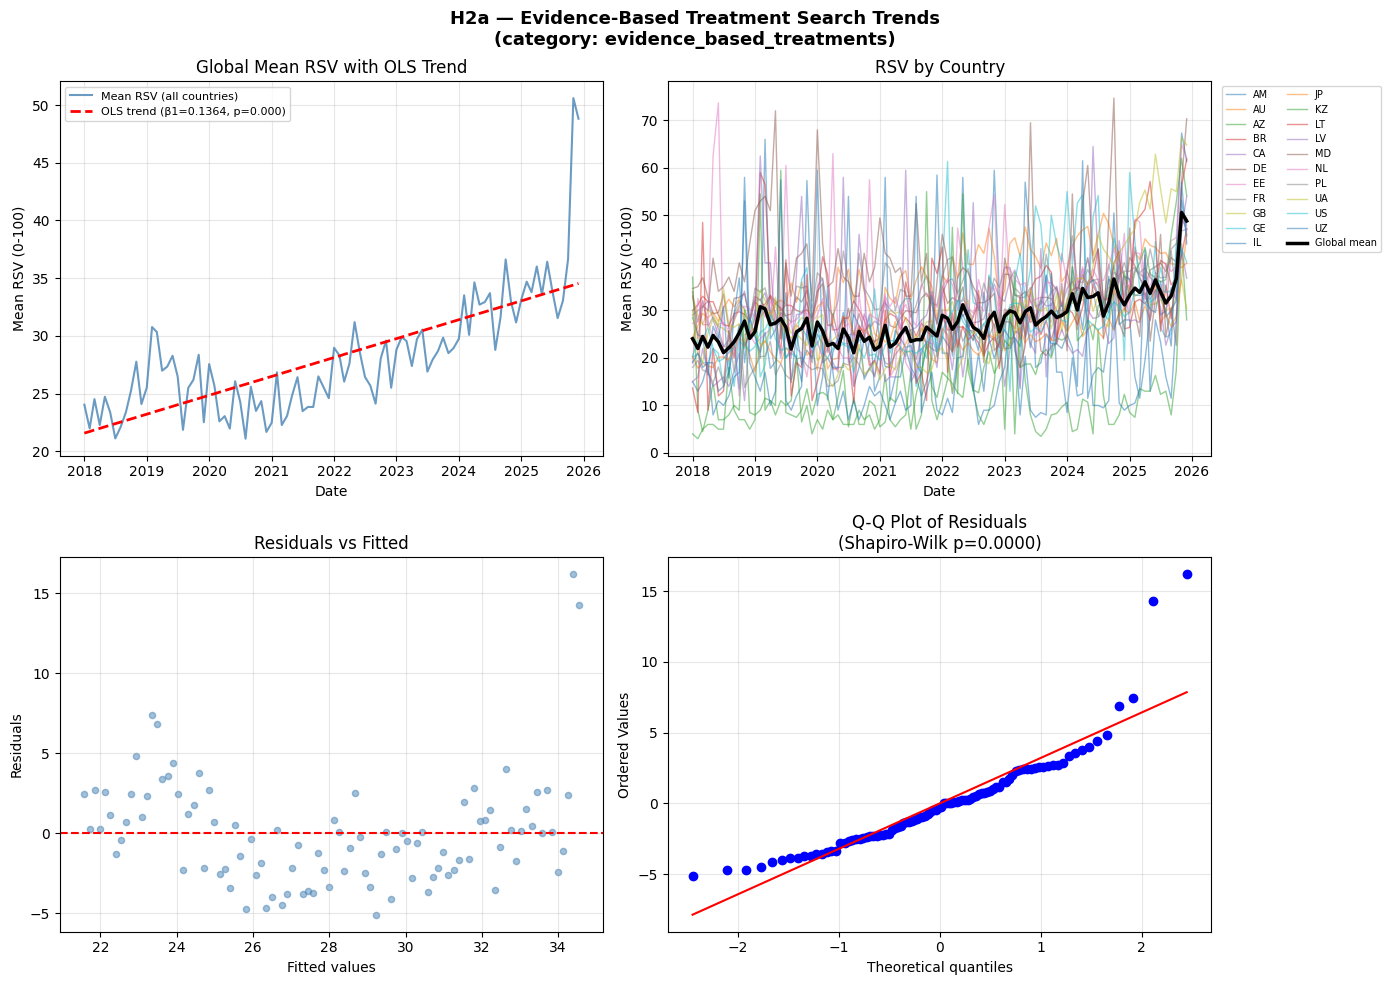

Figure saved to ..\results\H2a\H2a_trend_analysis.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'H2a — Evidence-Based Treatment Search Trends\n(category: {CATEGORY})',
             fontsize=13, fontweight='bold')

# ── Plot 1: Global mean trend with OLS line ─────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(y_global.index, y_global.values, color='steelblue', linewidth=1.5,
         alpha=0.8, label='Mean RSV (all countries)')
y_fit = beta0 + beta1 * t   # fitted values from OLS
ax1.plot(y_global.index, y_fit, color='red', linewidth=2,
         linestyle='--', label=f'OLS trend (β1={beta1:.4f}, p={p_val:.3f})')
ax1.set_title('Global Mean RSV with OLS Trend')
ax1.set_xlabel('Date')
ax1.set_ylabel('Mean RSV (0-100)')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_locator(mdates.YearLocator())    # tick every year
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Plot 2: Per-country spaghetti plot ──────────────────────────────────────────
ax2 = axes[0, 1]
for col in panel.columns:
    ax2.plot(panel.index, panel[col], linewidth=1, alpha=0.5, label=col)
ax2.plot(y_global.index, y_global.values, color='black',
         linewidth=2.5, label='Global mean', zorder=5)  # zorder=5: draw on top
ax2.set_title('RSV by Country')
ax2.set_xlabel('Date')
ax2.set_ylabel('Mean RSV (0-100)')
ax2.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Plot 3: Residuals vs Fitted — visual check of homoscedasticity ──────────────
ax3 = axes[1, 0]
ax3.scatter(model.fittedvalues, residuals, alpha=0.5, color='steelblue', s=20)
ax3.axhline(0, color='red', linestyle='--')  # reference line at zero
ax3.set_title('Residuals vs Fitted')
ax3.set_xlabel('Fitted values')
ax3.set_ylabel('Residuals')
ax3.grid(alpha=0.3)

# ── Plot 4: Q-Q plot — visual check of normality ────────────────────────────────
ax4 = axes[1, 1]
stats.probplot(residuals, dist='norm', plot=ax4)  # points on diagonal = normal
ax4.set_title(f'Q-Q Plot of Residuals\n(Shapiro-Wilk p={sw_p:.4f})')
ax4.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'H2a_trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {OUTPUT_DIR / "H2a_trend_analysis.png"}')


## 7. Export results

In [9]:
results = {
    'hypothesis': 'H2a',
    'category': CATEGORY,
    'n_months': int(len(y_ols)),
    'n_countries': int(panel.shape[1]),
    'excluded_countries': missing_report,

    # OLS results
    'ols': {
        'beta0': round(float(beta0), 4),
        'beta1': round(float(beta1), 4),
        'beta1_ci_lower': round(float(ci[1][0]), 4),
        'beta1_ci_upper': round(float(ci[1][1]), 4),
        'p_value': round(float(p_val), 4),
        'r_squared': round(float(r2), 4),
        'significant': bool(p_val < ALPHA_BONF and beta1 > 0),
    },

    # Assumption checks
    'assumptions': {
        'shapiro_wilk_stat': round(float(sw_stat), 4),
        'shapiro_wilk_p': round(float(sw_p), 4),
        'normality_ok': bool(normality_ok),
        'breusch_pagan_stat': round(float(bp_stat), 4),
        'breusch_pagan_p': round(float(bp_p), 4),
        'homoscedasticity_ok': bool(homoscedasticity_ok),
        'assumptions_met': bool(assumptions_ok),
    },

    # Mann-Kendall results
    'mann_kendall': {
        'trend': mk_result.trend,
        'tau': round(float(mk_result.Tau), 4),
        'p_value': round(float(mk_result.p), 4),
        'z': round(float(mk_result.z), 4),
        'significant': bool(mk_result.p < ALPHA_BONF and mk_result.trend == 'increasing'),
    },

    'primary_method': 'OLS' if assumptions_ok else 'Mann-Kendall',
    'alpha_bonferroni': ALPHA_BONF,
}

# Save full results as JSON — used by paper writing scripts
results_path = OUTPUT_DIR / 'H2a_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

# Save monthly time series for reproducibility
df_export = pd.DataFrame({'date': y_global.index, 'mean_rsv_global': y_global.values})
df_export.to_csv(OUTPUT_DIR / 'H2a_monthly_data.csv', index=False)

print('Results saved:')
print(f'  {results_path}')
print(f'  {OUTPUT_DIR / "H2a_monthly_data.csv"}')
print()
print('═' * 50)
print('SUMMARY')
print('═' * 50)
print(f'Primary method:  {results["primary_method"]}')
if results['primary_method'] == 'OLS':
    r = results['ols']
    print(f'β1 = {r["beta1"]}, p = {r["p_value"]}, R² = {r["r_squared"]}')
    print(f'H2a: {"SUPPORTED" if r["significant"] else "NOT SUPPORTED"}')
else:
    r = results['mann_kendall']
    print(f'τ = {r["tau"]}, p = {r["p_value"]}, trend = {r["trend"]}')
    print(f'H2a: {"SUPPORTED" if r["significant"] else "NOT SUPPORTED"}')


Results saved:
  ..\results\H2a\H2a_results.json
  ..\results\H2a\H2a_monthly_data.csv

══════════════════════════════════════════════════
SUMMARY
══════════════════════════════════════════════════
Primary method:  Mann-Kendall
τ = 0.5996, p = 0.0, trend = increasing
H2a: SUPPORTED
